In [ ]:
import yaml
from pathlib import Path

%load_ext autoreload
%autoreload 2


Loaded 1 simulations from smith1_openai_large.yaml_20260502_230453
  Iteration history rows: 1500
  Transaction rows:       0 (no transactions_*.csv found)
  Rounds per sim:         5

Competitive Equilibrium:
  Quantity:       6
  Price:          2.0000
  Total surplus:  7.5000
  Buyer surplus:  3.75
  Seller surplus: 3.75
  Demand:         [3.25 3.   2.75 2.5  2.25 2.   1.75 1.5  1.25 1.   0.75]
  Supply:         [0.75 1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   3.25]


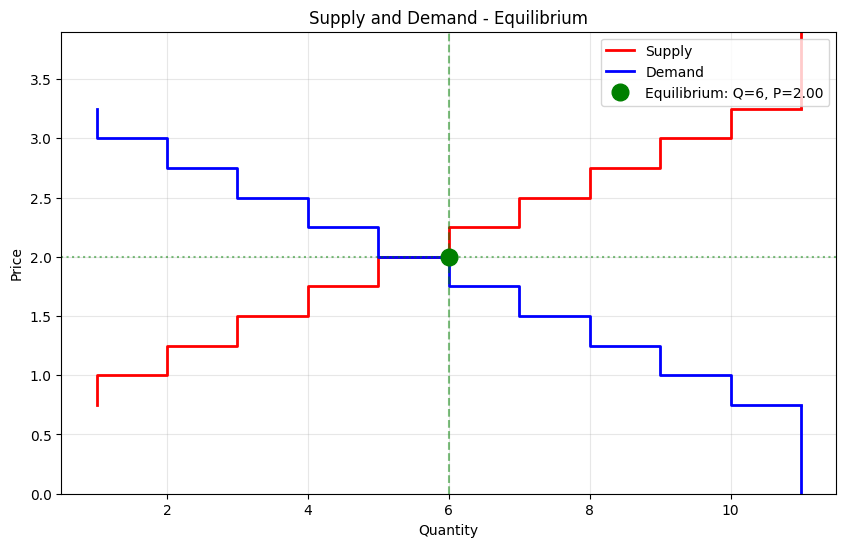


NO TRANSACTIONS â€” skipping efficiency, alpha, Marshallian, and summary table

RENT-SEEKING ANALYSIS

Attempted Rent (submitted order prices):
   Buyer: mean=1.503, median=1.480, std=0.786
  Seller: mean=0.649, median=0.640, std=0.387

Concessions (submitted order prices):
   Buyer: mean concession=0.092, frac=9.2%
  Seller: mean concession=0.046, frac=11.3%

Constraint Violations:
  Announcements: 0/1007 (0.0%)

Fill Rate (fraction of submitted orders that executed immediately):
   Buyer: 0.0%
  Seller: 0.0%


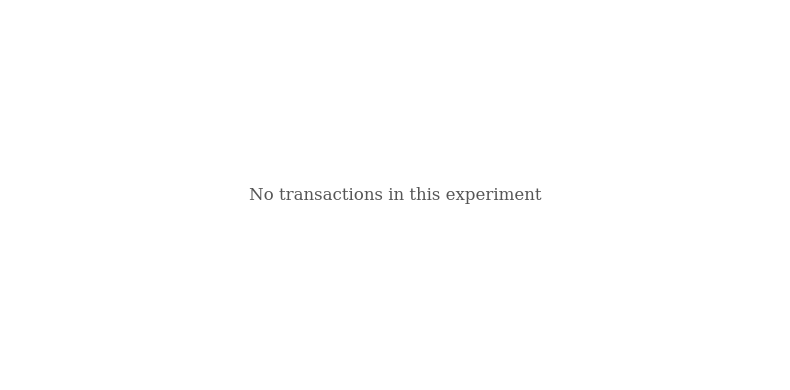

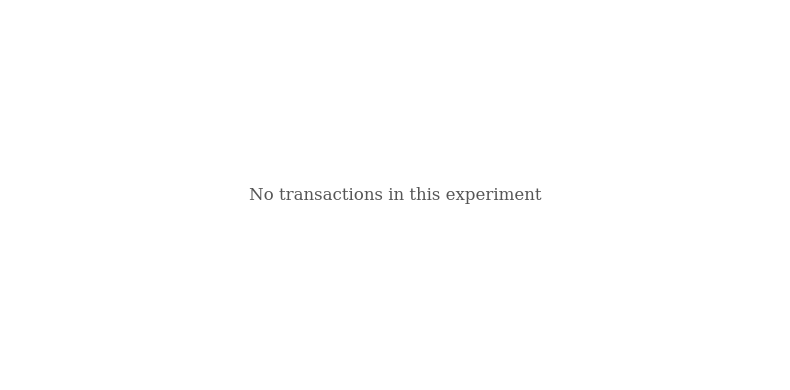

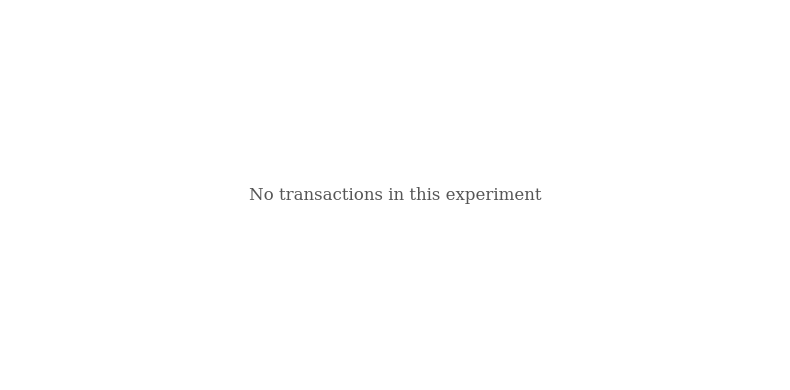

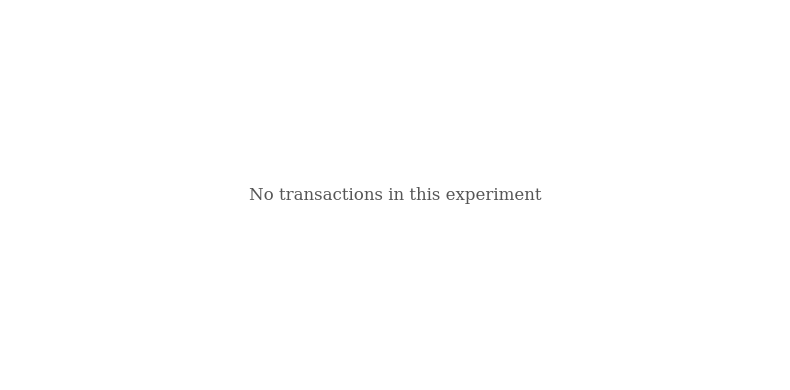

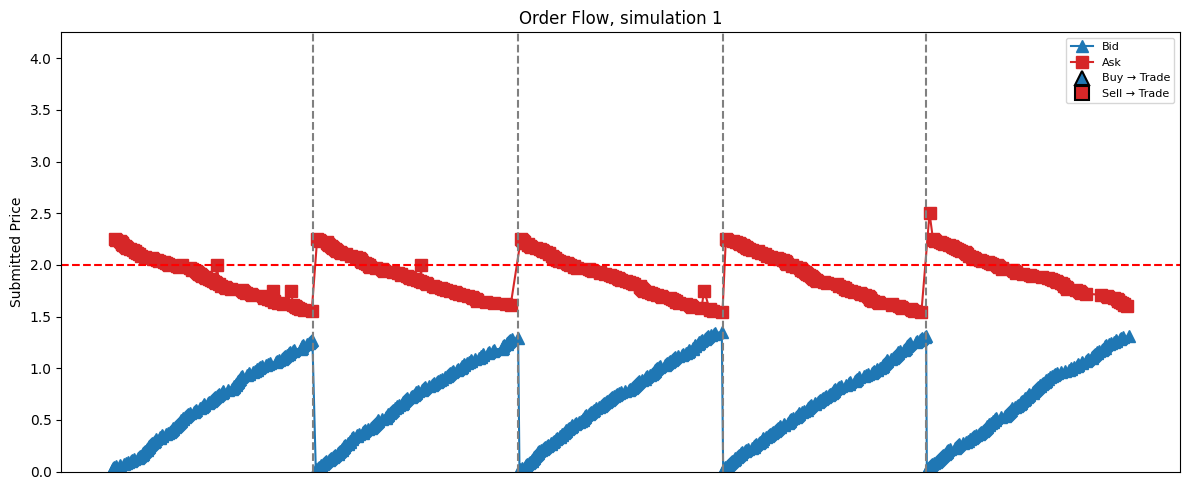

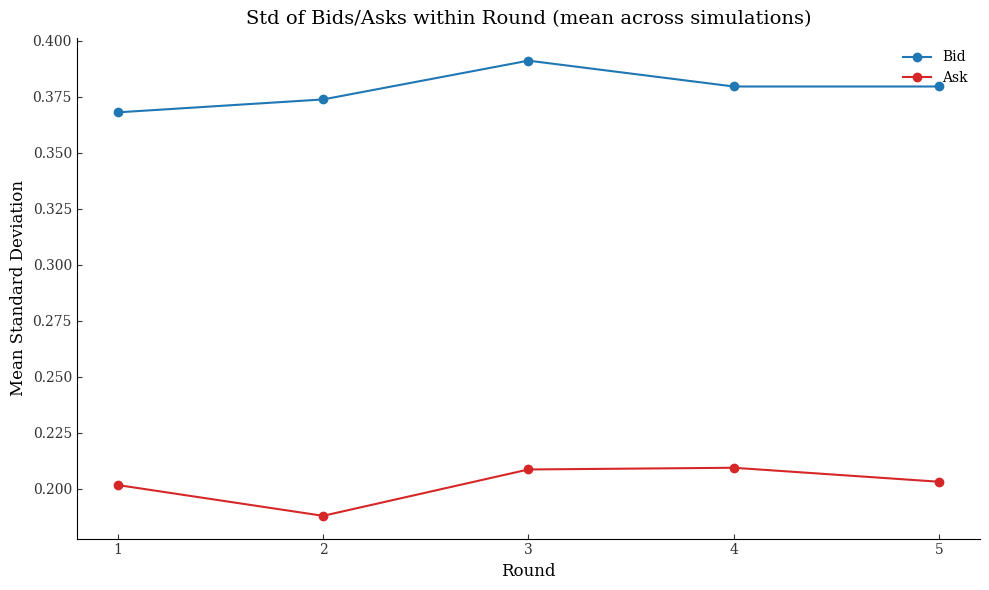

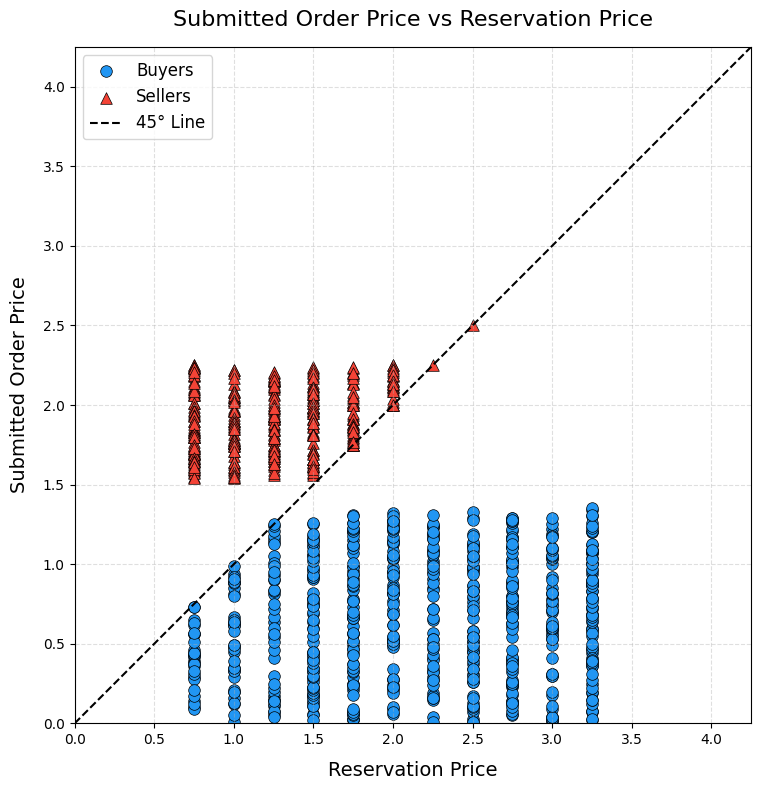

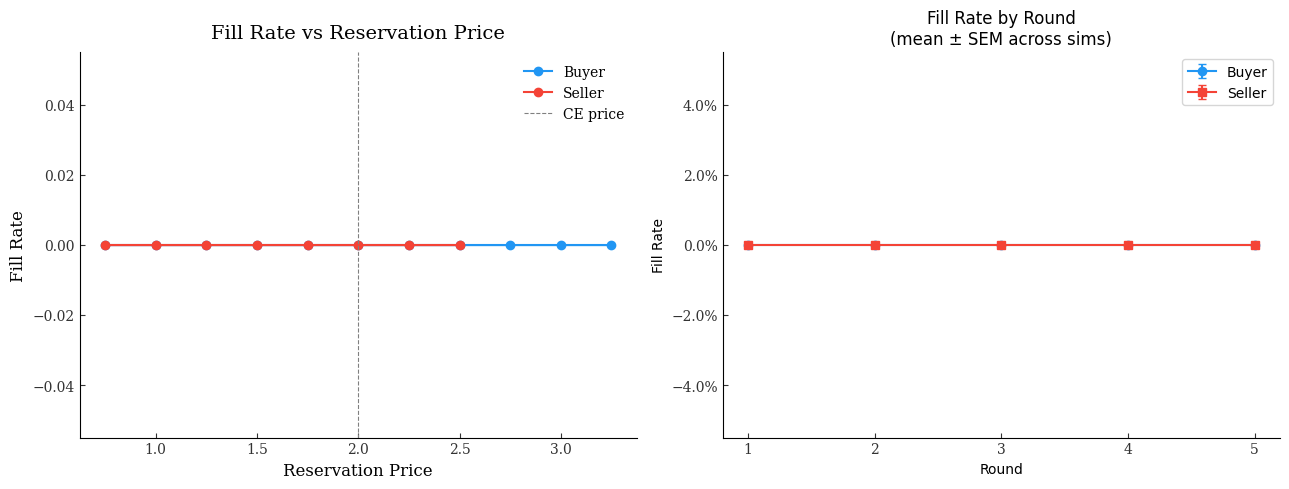

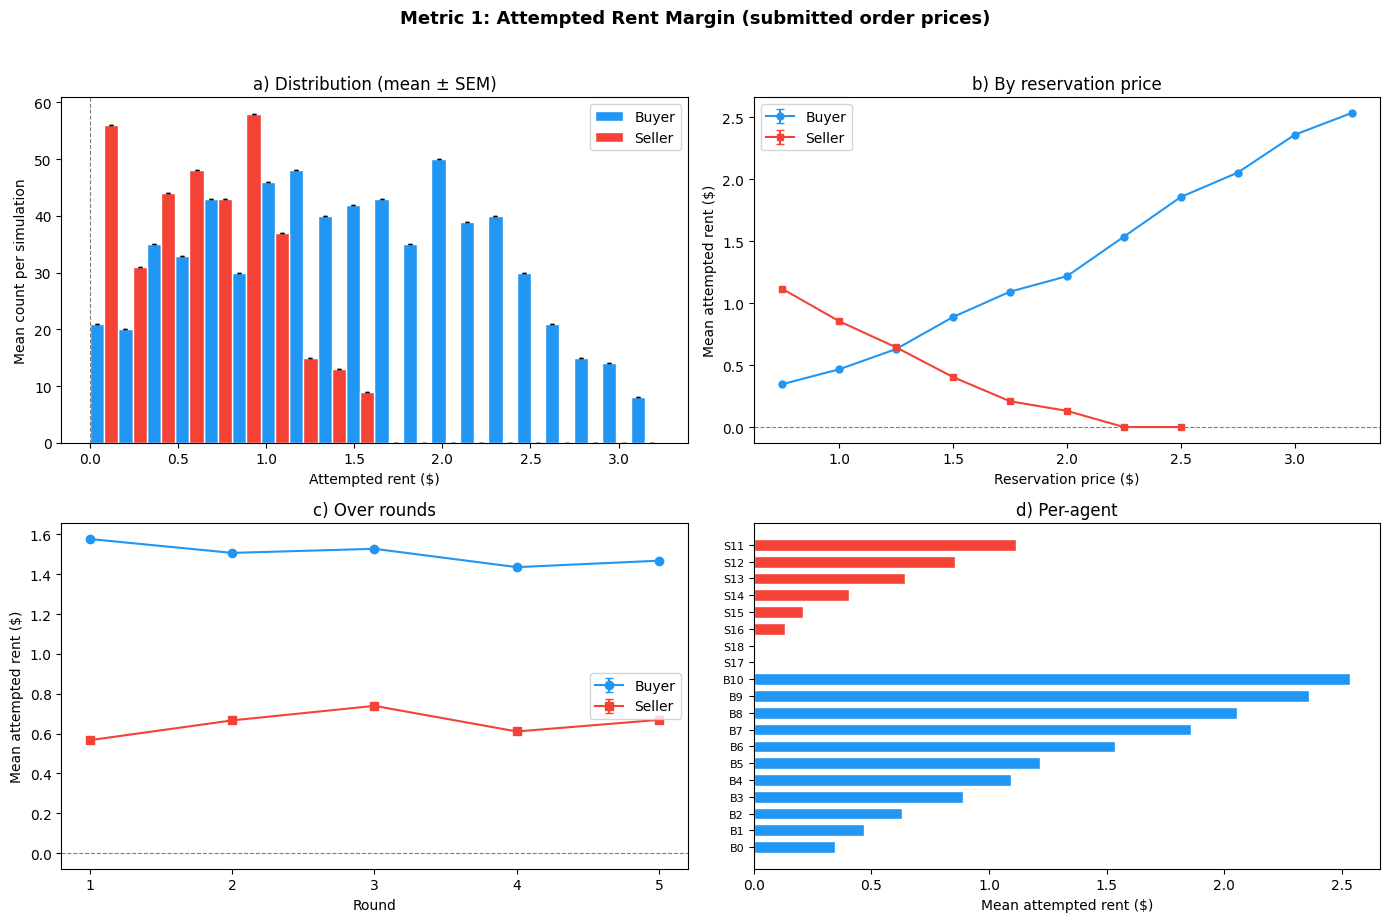

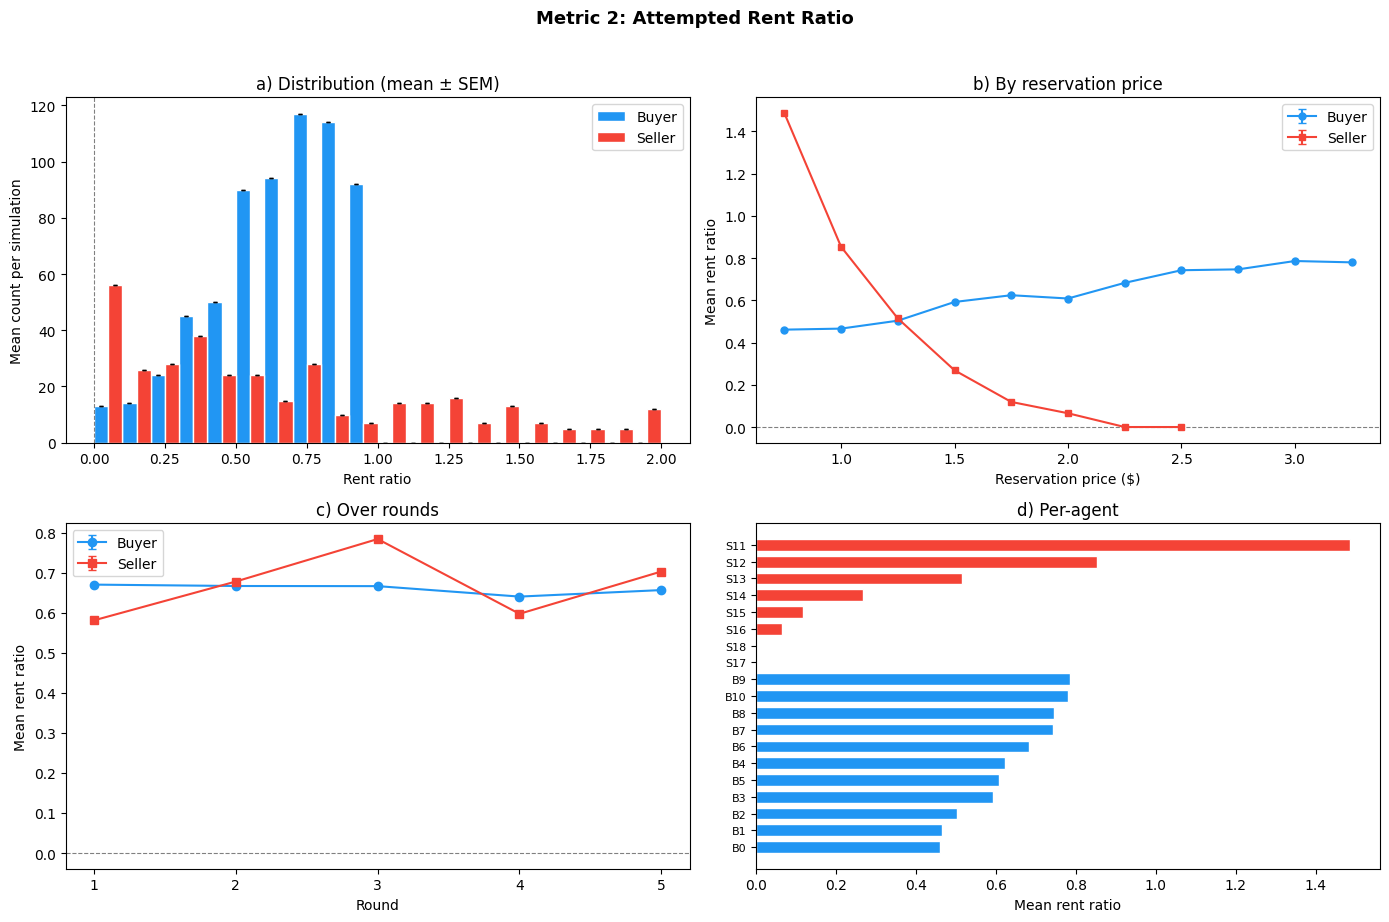

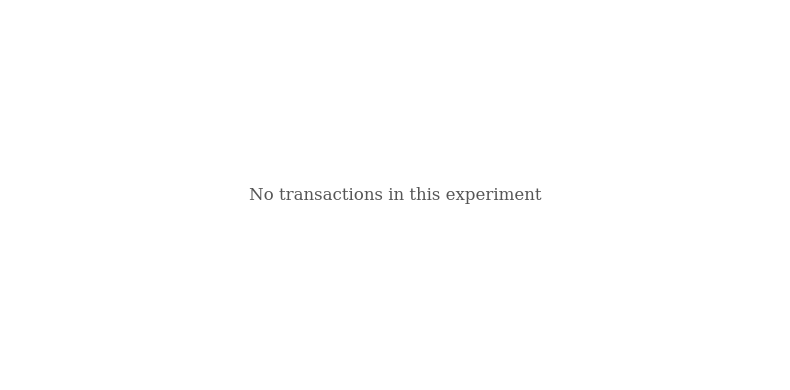

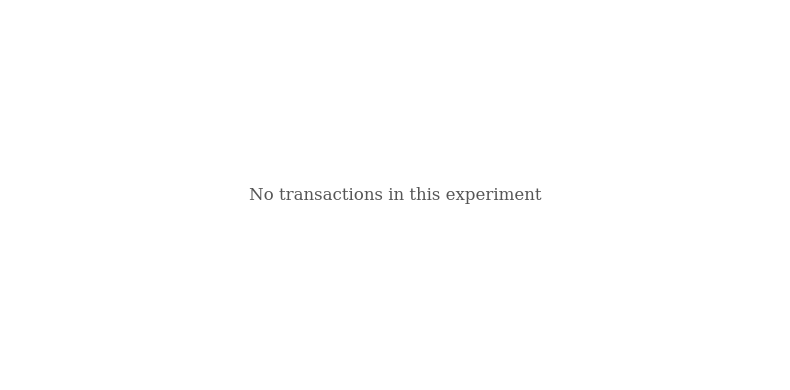

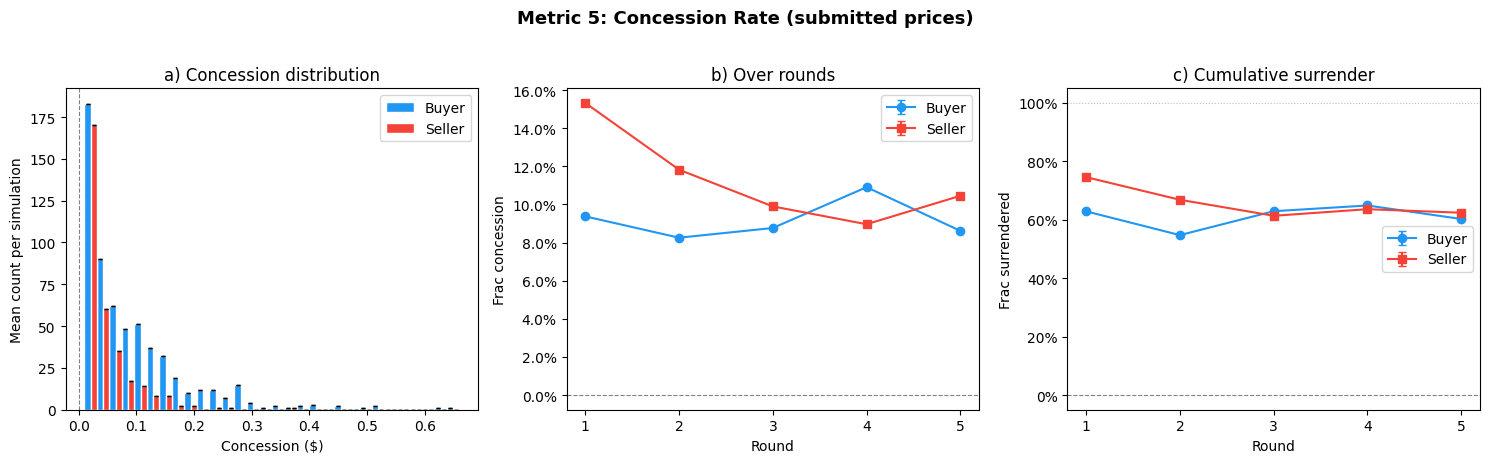

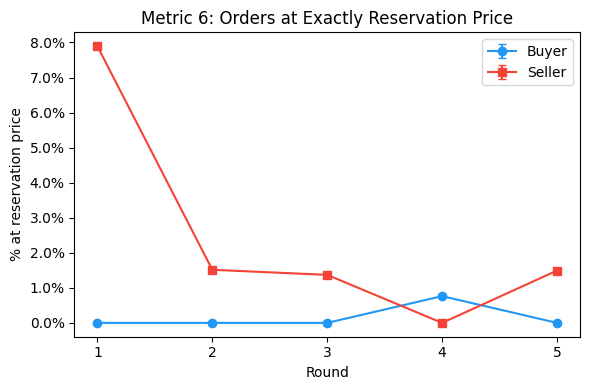

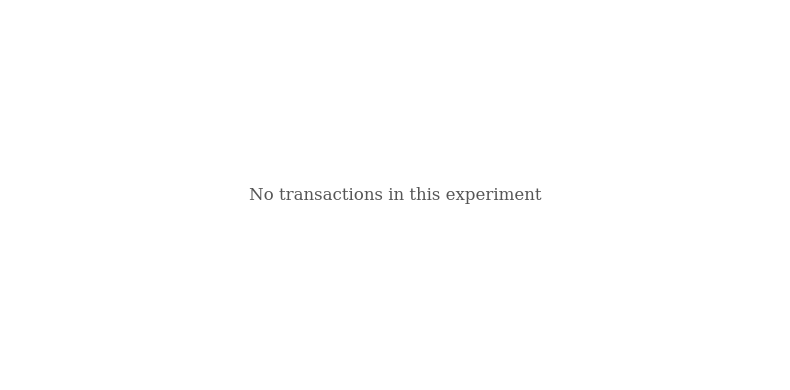

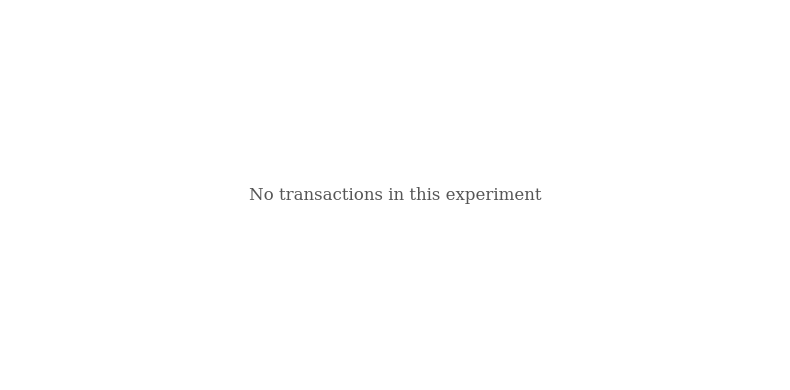

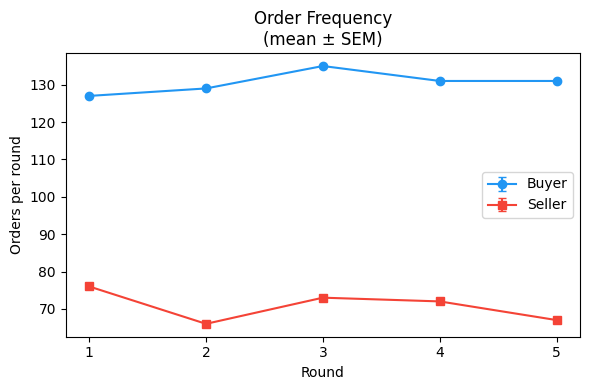

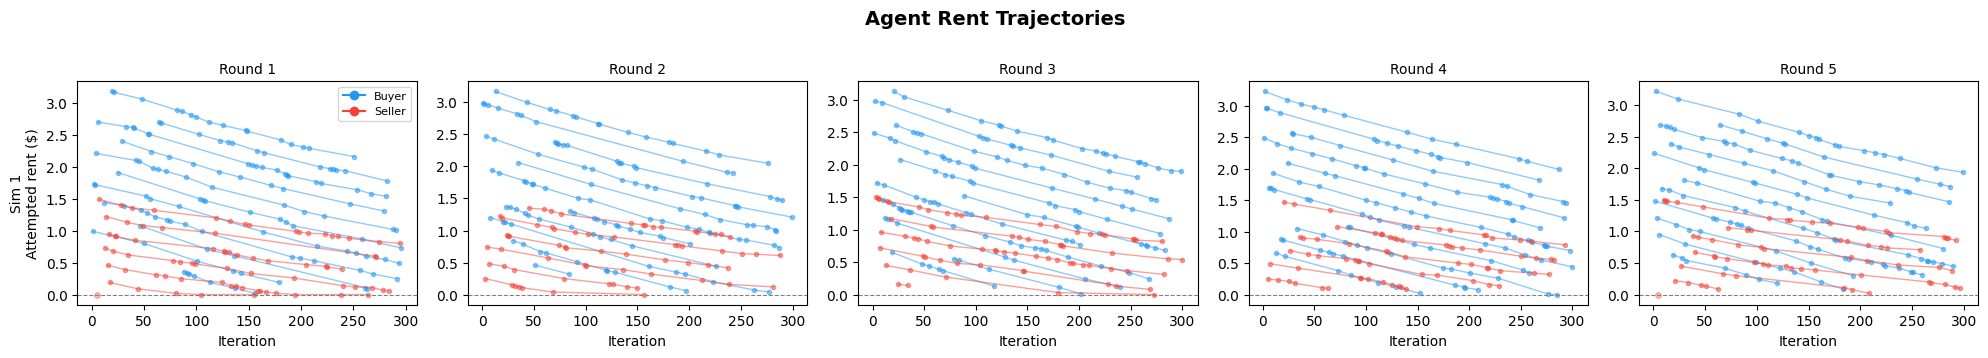

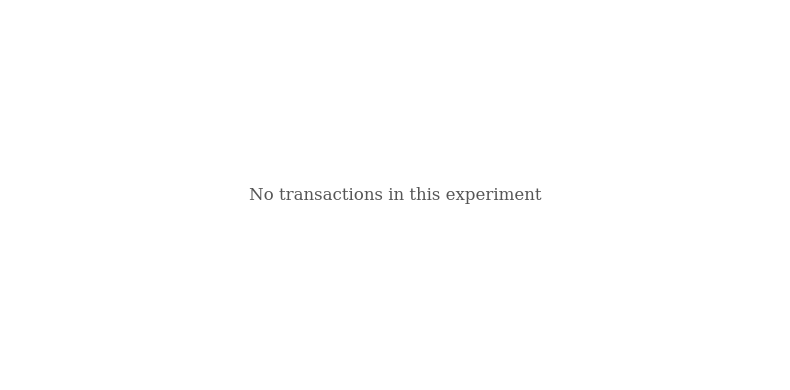

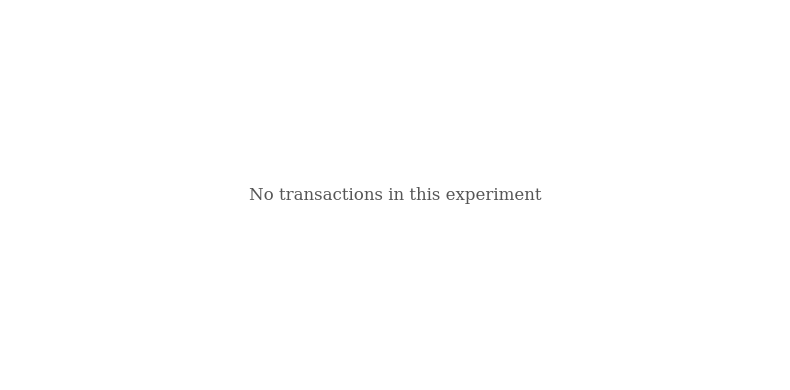

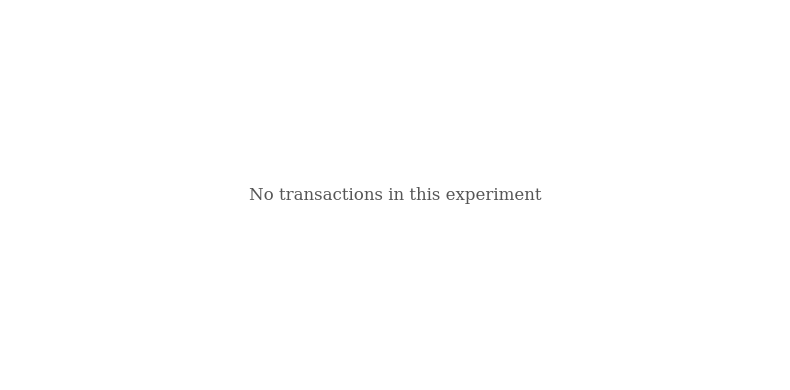

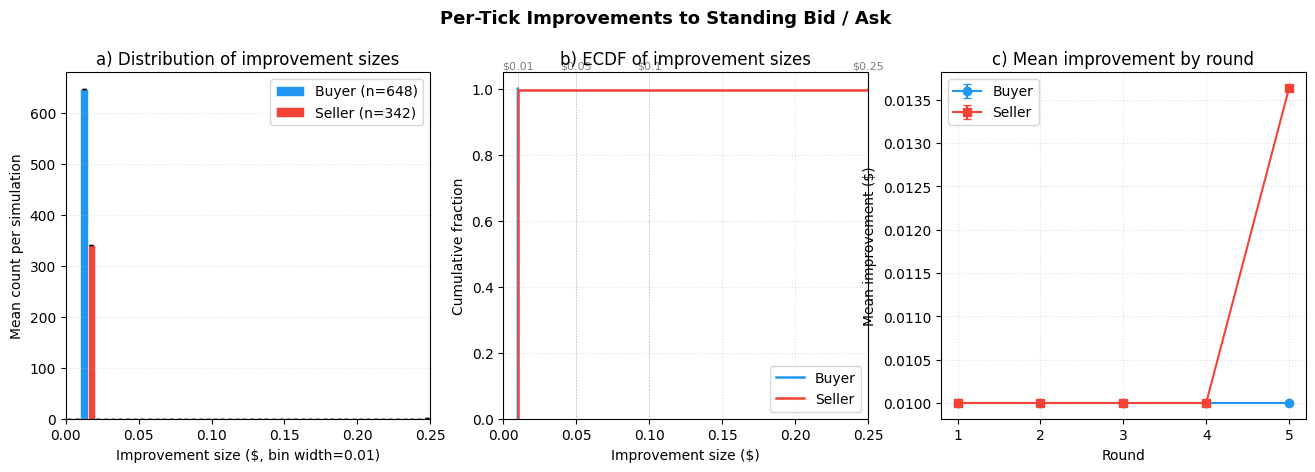

In [68]:
from results_analysis_utils import run_full_analysis

# experiment_id = r"final\results_configs_final\smith1_gemini_large.yaml_20260502_225103"
# experiment_id = r"final\results_configs_final\smith1_gemini_small.yaml_20260502_224517"
experiment_id = r"final\results_configs_final\smith1_openai_large.yaml_20260502_230453"
# experiment_id = r"final\results_configs_final\smith1_openai_small.yaml_20260502_224940"
# experiment_id = r"final\results_configs_final\smith2_gemini_small.yaml_20260503_115428"
# experiment_id = r"final\results_configs_final\smith2_openai_large.yaml_20260503_113239"
# experiment_id = r"final\results_configs_final\smith2_openai_small.yaml_20260502_231606"
# experiment_id = r"final\results_configs_final\smith4a_openai_large.yaml_20260503_121853"
# experiment_id = r"final\results_configs_final\smith4a_openai_small.yaml_20260503_114229"

# ablations
# experiment_id = "final/ablations/smith1_openai_large_max_profit_removed_20260505_192131"
# experiment_id = "final/configs_non_reason/smith1_gemini_large_zeroprofit.yaml_20260505_235057"
# experiment_id = r"final\configs_non_reason\smith1_gemini_small_zeroprofit.yaml_20260505_231858"
# experiment_id = r"final\configs_non_reason\smith1_openai_large_zeroprofit.yaml_20260505_235018"
# experiment_id = r"final\configs_non_reason\smith1_openai_small_zeroprofit.yaml_20260505_231318"


independent_rounds = False  # set to True if you are testing a ZI simulation with multiple rounds (legacy)

root_path = Path(globals()['_dh'][0]).parent
results_path = root_path / 'results' / experiment_id

# read the number of simulations from the config file
with open(results_path / 'config_used.yaml', "r") as f:
    config = yaml.safe_load(f)
n_sims = config['experiment']['n_simulations']

# Single experiment — now returns (data, metrics, figs) instead of a flat dict
data, metrics, figs = run_full_analysis(
    results_path,
    n_sims,
    config=config,
    experiment_id=experiment_id,
    independent_rounds=independent_rounds)


# Access the DataFrames for further analysis
# df_metrics = metrics.round_metrics   # per-round efficiency, alpha, etc.
# df_marsh = metrics.marshallian       # per-transaction Marshallian path data
# eq = data.eq                         # Equilibrium object (price, quantity, surplus, maps)
# rent = metrics.rent                  # dict of rent-seeking DataFrames
# figs['attempted_rent']               # individual figures by name (no 'fig_' prefix)